# 2.군집화 머신 러닝 모델 만들기

### 사과 데이터를 가지고 군집화 모델 만들기

속성(feature) : 품종, 지역, 과중, 종경, 횡경, 경도, 당도, 산도, 착색

적용 알고리즘 : K 평균 군집화 알고리즘

질문1 : 군집화 모델을 만들면 몇 개의 군집이 만들어질까?

질문2 : 만들 군집의 개수를 지정해서 만들면 적당하게 군집화를 수행할까?

### 데이터 전처리

In [1]:
import numpy as np
import pandas as pd

# 데이터를 가져오기
df = pd.read_excel("사과-군집화.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   kind    76 non-null     object 
 1   region  76 non-null     object 
 2   weight  76 non-null     float64
 3   height  76 non-null     float64
 4   width   76 non-null     float64
 5   sugar   76 non-null     float64
 6   sour    76 non-null     float64
dtypes: float64(5), object(2)
memory usage: 4.3+ KB


In [2]:
df['kind'].value_counts()

홍로    39
후지    37
Name: kind, dtype: int64

In [3]:
#품종 데이터를 숫자형으로 변환
# 홍로 -> 1, 후지 -> 2
df.replace({'kind':{'홍로':1, '후지':2}},inplace=True)
df

,kind,region,weight,height,width,sugar,sour
0,2,거창,283.6,78.3,87.0,13.0,0.39
1,1,거창,229.0,73.9,81.6,11.4,0.29
2,2,거창,266.5,73.9,86.1,12.3,0.37
3,1,거창,176.7,66.8,73.7,11.0,0.31
4,1,군위,308.6,83.3,90.7,15.2,0.19
...,...,...,...,...,...,...,...
71,2,화성,384.2,85.9,96.4,14.1,0.51
72,1,화성,311.3,82.9,90.5,12.7,0.25
73,2,화성,284.3,78.2,88.0,13.6,0.36
74,1,화성,324.0,88.4,92.1,12.6,0.22


In [4]:
df['region'].value_counts()

포천     10
화성     10
김제      8
군위      7
충주      7
완주      6
영주      5
장수      5
청송      5
거창      4
남해      4
춘천      4
완주2     1
Name: region, dtype: int64

In [5]:
#지역 데이터를 숫자형으로 변환
# 레이블 인코딩 모듈 사용 - 항목값에 무작위로 수치를 부여함

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['region'] = encoder.fit_transform(df['region'])
print(encoder.classes_)
df

['거창' '군위' '김제' '남해' '영주' '완주' '완주2' '장수' '청송' '춘천' '충주' '포천' '화성']


,kind,region,weight,height,width,sugar,sour
0,2,0,283.6,78.3,87.0,13.0,0.39
1,1,0,229.0,73.9,81.6,11.4,0.29
2,2,0,266.5,73.9,86.1,12.3,0.37
3,1,0,176.7,66.8,73.7,11.0,0.31
4,1,1,308.6,83.3,90.7,15.2,0.19
...,...,...,...,...,...,...,...
71,2,12,384.2,85.9,96.4,14.1,0.51
72,1,12,311.3,82.9,90.5,12.7,0.25
73,2,12,284.3,78.2,88.0,13.6,0.36
74,1,12,324.0,88.4,92.1,12.6,0.22


### 모델 생성 및 학습 

In [6]:
#필요한 모듈 import
from sklearn.cluster import KMeans


model1 = KMeans(n_clusters=6, random_state=0) #모델을 선언

model1.fit(df)    # 학습

#결과 확인
print(model1.labels_)
print(np.unique(model1.labels_, return_counts=True))


[0 4 4 2 3 0 3 4 0 2 4 0 3 0 1 5 1 5 0 1 2 5 2 0 3 1 0 3 2 0 4 0 0 4 4 0 4
 4 0 0 4 0 4 4 0 4 4 4 4 0 3 4 4 3 1 4 3 1 0 3 4 3 4 4 3 3 3 1 0 0 5 1 3 0
 3 0]
(array([0, 1, 2, 3, 4, 5]), array([22,  8,  5, 15, 22,  4], dtype=int64))


### 모델 평가 - 결과 데이터 분석

In [7]:
#기존의 데이터에 군집 분류한 labels을 붙여주기
df_c1 = df.copy()
df_c1['cluster'] = model1.labels_
df_c1

,kind,region,weight,height,width,sugar,sour,cluster
0,2,0,283.6,78.3,87.0,13.0,0.39,0
1,1,0,229.0,73.9,81.6,11.4,0.29,4
2,2,0,266.5,73.9,86.1,12.3,0.37,4
3,1,0,176.7,66.8,73.7,11.0,0.31,2
4,1,1,308.6,83.3,90.7,15.2,0.19,3
...,...,...,...,...,...,...,...,...
71,2,12,384.2,85.9,96.4,14.1,0.51,1
72,1,12,311.3,82.9,90.5,12.7,0.25,3
73,2,12,284.3,78.2,88.0,13.6,0.36,0
74,1,12,324.0,88.4,92.1,12.6,0.22,3


In [8]:
df_c1.groupby('cluster').mean()

,kind,region,weight,height,width,sugar,sour
cluster,,,,,,,
0,1.500000,6.227273,288.659091,79.572727,88.336364,13.709091,0.304545
1,1.875000,7.000000,366.712500,85.612500,95.425000,14.075000,0.358750
2,1.000000,2.400000,182.100000,67.700000,74.480000,13.940000,0.256000
3,1.533333,8.200000,324.413333,82.900000,92.093333,14.053333,0.318000
4,1.454545,7.045455,250.027273,74.554545,84.400000,13.686364,0.319091
5,1.250000,4.750000,420.500000,90.300000,96.475000,14.900000,0.307500


In [9]:
df_c1.groupby('cluster')['weight'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,22.0,288.659091,10.969250,270.4,281.000,286.75,298.250,305.8
1,8.0,366.712500,15.358519,348.6,352.850,366.50,379.475,384.4
2,5.0,182.100000,29.155703,134.3,176.700,191.40,199.800,208.3
3,15.0,324.413333,10.115184,308.6,317.100,324.00,331.300,341.6
4,22.0,250.027273,11.804163,221.3,246.650,250.90,259.650,266.5
5,4.0,420.500000,23.839603,402.8,404.075,412.50,428.925,454.2


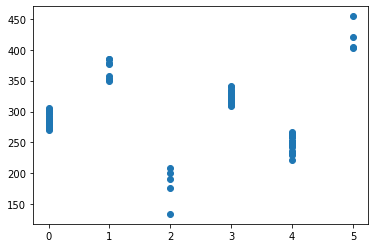

In [10]:
import matplotlib.pyplot as plt

plt.scatter(df_c1['cluster'],df_c1['weight'])
plt.show()

- 군집화로 분류하는데 있어서 'heavy'(무게) 항목이 분류 기준 중 하나임을 짐작할 수 있음. 즉, 사과의 무게에 따라 군집화를 수행함

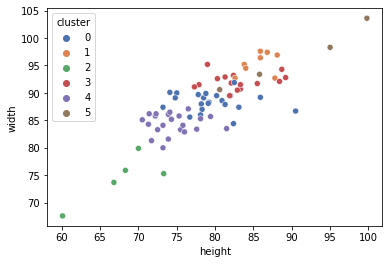

In [11]:
import seaborn as sns
sns.scatterplot(data = df_c1, x='height',y='width',hue='cluster',palette='deep')
plt.show()

- 군집화로 분류하는데 있어서 'height'(세로길이), 'width'(가로길이) 항목이 뷴류 기준 중 하나임을 짐잠할 수 있다. 즉, 사과의 크기에 따라 군집화를 수행함

In [12]:
#농산물 표준 규격에 맞는 크기에 대한 정보를 군집한 결과와 결합하기

df_c1['grade'] = 0
df_c1.loc[(df_c1['weight']>=375),'grade'] = 6
df_c1.loc[(df_c1['weight']<375) & (df_c1['weight']>=300),'grade'] = 5
df_c1.loc[(df_c1['weight']<300) & (df_c1['weight']>=250),'grade'] = 4
df_c1.loc[(df_c1['weight']<250) & (df_c1['weight']>=214),'grade'] = 3
df_c1.loc[(df_c1['weight']<214) & (df_c1['weight']>=188),'grade'] = 2
df_c1.loc[(df_c1['weight']<188) & (df_c1['weight']>=167),'grade'] = 1

df_c1

,kind,region,weight,height,width,sugar,sour,cluster,grade
0,2,0,283.6,78.3,87.0,13.0,0.39,0,4
1,1,0,229.0,73.9,81.6,11.4,0.29,4,3
2,2,0,266.5,73.9,86.1,12.3,0.37,4,4
3,1,0,176.7,66.8,73.7,11.0,0.31,2,1
4,1,1,308.6,83.3,90.7,15.2,0.19,3,5
...,...,...,...,...,...,...,...,...,...
71,2,12,384.2,85.9,96.4,14.1,0.51,1,6
72,1,12,311.3,82.9,90.5,12.7,0.25,3,5
73,2,12,284.3,78.2,88.0,13.6,0.36,0,4
74,1,12,324.0,88.4,92.1,12.6,0.22,3,5


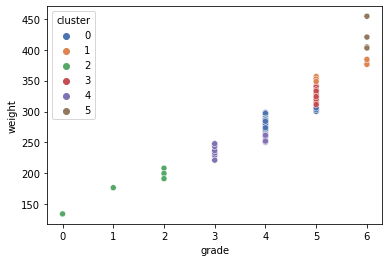

In [13]:
sns.scatterplot(data=df_c1, x='grade',y='weight',
                hue='cluster',palette='deep')
plt.show()

- 농산물 표준 규격과 군집화 결과가 정확하게 일치하는 것은 아니지만, 대략적으로 일치한다는 것을 확인할 수 있음

### 실루엣 분석

In [14]:
from sklearn.metrics import silhouette_samples,silhouette_score

avg_score = silhouette_score(df, model1.labels_)
print('평균 실루엣 계수 =',avg_score)

samples = silhouette_samples(df, model1.labels_)
score_df = pd.DataFrame({'cluster':model1.labels_, 'silhouette':samples})
score_df.groupby('cluster')['silhouette'].mean()

평균 실루엣 계수 = 0.47734050567848396


cluster
0    0.425892
1    0.397315
2    0.464979
3    0.498906
4    0.569654
5    0.347217
Name: silhouette, dtype: float64